<a href="https://colab.research.google.com/github/avaabarnes/A03-knn/blob/main/notebook_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Ava Barnes

**Date:** 9/20/2026

**Q1. Answers**
1. What is the difference between regression and classification?

Regressions is used to predict a numeric tagret, like price, and classification is to predict a categorical variable,like color.  

2. What is a confusion table? What does it help us understand about a model's performance?

A confusion table counts predictions by actual class and predicted class. It helps us understand how often a model correctly and incorrectly classifies each class.



3. What does the SSE quantify about a particular model?

The Sum of Squared Error measures the total squared difference between actual values and the model's predictions. A lower validation SSE means smaller errors in the validation set and higher means more errors.

4. What are overfitting and underfitting?

Overfitting occurs when a model is too complex, learning noise or specific patterns rather than general patterns from the training data. This can happen in a k-NN if that k value is very small. Underfitting occurs when a model over simplifies the data rather than capturing important patterns beause the k value is too large. Underfitting causes the model to make predictions off of too many nieghbors.


5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?

We fit models on a training set and then comapre their predictions on a separate validation set. The validation error helps estimate how a model will perform on future unknown data and help us pick the best k. We keep a test set for the final evalution when one is avaliable. This estimate depends on how we split the data and helps prevent the model from being selected to perform well on the evaluation data set instead of performing well on new, unseen data.


6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

A class label gives one clear prediction, which is simple and easy to interpret. However, the prediction does not show the model's confidence. The probability distribution gives the probability of each class, which provides more information about he model's confidence level, but can be harder to interpret.



In [ ]:
#Question 2 -----

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

#loading data and EDA
lm = pd.read_csv("/content/land_mines.csv")

print("shape:", lm.shape)
print('missing values per column:', lm.isna().sum()) #no missing values

#summary stats for three features
print('feature summaries: ', lm[["voltage", "height", "soil"]].describe())

#looking at amount of each mine type
print('mine type counts:', lm['mine_type'].value_counts().sort_index())

#printing mean of each mine type and features
print('Mean:', lm.groupby('mine_type').mean())



#spliting the sample into training and test/validation sets
lm_X_raw = lm[['voltage', 'height', 'soil']]
lm_y = lm['mine_type']
(
    lm_X_train_raw,
    lm_X_valid_raw,
    lm_y_train,
    lm_y_valid,
) = train_test_split(
    lm_X_raw, lm_y, test_size=0.50, stratify=lm_y, random_state=65
)

lm_scaler = MinMaxScaler()
lm_X_train_scaled = lm_scaler.fit_transform(lm_X_train_raw) #computing training data min and max and scaling the validation features
lm_X_valid_scaled = lm_scaler.transform(lm_X_valid_raw) #using same values to scale the validation features

#building k-NN classifier and choosing k value
lm_ks = np.arange(1,51) #trying k values from 1-50
lm_valid_acc = [] #empty list to store each k's accucray on validation set
lm_train_acc = [] #empty list to store each k's accuracy on training set

for lm_k in lm_ks: #looping through for each k
  lm_candidate =KNeighborsClassifier(n_neighbors=int(lm_k)) #building k-NN model using k
  lm_candidate.fit(lm_X_train_scaled, lm_y_train) #learning from the training mines (k-NN storing them)
  lm_valid_hat = lm_candidate.predict(lm_X_valid_scaled) #guessing the mine type of every validation mine
  lm_train_hat = lm_candidate.predict(lm_X_train_scaled) #guess mine type for train set also
  lm_valid_acc.append(np.mean(lm_y_valid.to_numpy()== lm_valid_hat)) #saving correct validation guesses
  lm_train_acc.append(np.mean(lm_y_train.to_numpy()== lm_train_hat)) #saving correct training guesses

best_k = int(lm_ks[np.argmax(lm_valid_acc)]) #finding position of highest validation accuracy, finding that k value
print('Best k:', best_k)

#creating plot of training v validation accuracy for each k, used to choose k
plt.plot(lm_ks, lm_train_acc, label='Training accuracy')
plt.plot(lm_ks, lm_valid_acc, label='Validation accuracy')
plt.axvline(best_k, color='red', linestyle='--', label=f'best k = {best_k}')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#print a confusion table
lm_final = KNeighborsClassifier(n_neighbors=best_k) #refitting model using the best k
lm_final.fit(lm_X_train_scaled, lm_y_train) #train on the training data
lm_pred = lm_final.predict(lm_X_valid_scaled) #predict the validation data

#creating confusion table, rows = actual and columns = predicted
print(pd.crosstab(lm_y_valid, lm_pred, rownames=['actual'], colnames=['predicted']))

#printing overall accuracy
print('accuracy:', np.mean(lm_y_valid.to_numpy() == lm_pred))


shape: (338, 4)
missing values per column: voltage      0
height       0
soil         0
mine_type    0
dtype: int64
feature summaries:            voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000
mine type counts: mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
Mean:             voltage    height      soil
mine_type                              
1          0.296463  0.495519  0.492958
2          0.721123  0.487013  0.508571
3          0.402408  0.527548  0.496970
4          0.345365  0.506887  0.503030
5          0.379598  0.530070  0.516923
Best k: 2
predicted   1   2   3   4  5
actual                      
1          27   0   5   2  2
2        

Question 2: written answers

3. Explain how you select k

I selected k by trying every value from 1 to 50, which covers a flexible model, small k values, and smooth ones, large k values. For each k, I fit and trained a k-NN classifer on the training data and measured its accuracy on the validation half, which the model had not seen. I chose the k with the highest validation accuracy because it performed best on the validation data (data it hadn't seen during training). This value was k = 2.

4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?

The model is overall 46.7% accurate. It performs best for the class 2 mine type predicting 31 out of 35 observations correctly. It also performed well for class 1, predicting 27 out of 36 observations correctly. It performs less accurately for classes 3, 4, and 5. It performed the worst for class 5, only correctly predicting 2 out of 32 observations.


5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

Due to these errors, I would advise somoeone against treating the prediction label as a final answer. First, I would advise someone to use the model to narrow the possibilities while not making the final call for how to remove a mine. The model performs much better for some min type than others, so predictions should be interpreted differently. For example, the model's predictions for type 2 is very reliable so it could be a trusted prediction when backed up by additional metrics. However, for types 1, 3, 4, and 5 which have lower accuracy levels, the prediction could be interpretted as much less reliable and should be confirmed by

Second, I would confirm the models predictiosn with additional information and data before removing a mine. This could include another sensor reading, visual inspection, and judgment from experts. This would be especially critical for the 3, 4, and 5 types because the model makes the most mistake there.

Third, I would try to collect more data to train the model on. This would help the model become more accurate since there would be more training data for it to learn from.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** f1a1c3aabf2dbd95a062a4f296ac54b2974a90ad
- **AI tool and model used:** Claude Sonnet 5.5

### *Prompts used

1. Give me feedback to improve this assignment for my ML class, given this rubric, instructions, data, and my code (inserted rubric, instructions, data, and code)

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Biggest issues (Q2)

1. k = 2 is a fragile choice, and it creates a hidden problem (2.4, 2.5).

With two neighbors, 72% of your validation points had neighbors that disagreed. scikit-learn breaks those ties toward the lowest class label.
That is why your confusion table has 67 predictions of "1" when only 36 mines are type 1, and only 6 predictions of "5". Part of the "class 5 is hard" story is a tie-breaking artifact rather than a property of the mines.
The selection is also noisy. With 169 validation points, one observation is about 0.6 percentage points, and your accuracy curve jumps around by 3–8 points between adjacent k values. Across other random seeds, k = 2 won in 7 of 8, but with accuracy ranging from 42% to 50%. Repeated 5-fold CV on all the data gave about 45% for both k = 2 and k = 3, so you can't distinguish them.
Suggestions: prefer odd k to avoid ties, or at least say that ties exist and how they're resolved. Consider cross-validation, or the simplest k within one standard error of the best, instead of a raw argmax from one split.

2. You use the same half to pick k and to report accuracy (2.5, 2.6).

Your 46.7% is the maximum of 50 numbers computed on that half, so it's optimistically biased. The assignment's wording invites this setup, but a strong answer should say so. It also connects directly to your Q1.5 answer.
You never interpret your own plot. Training accuracy is 100% at k = 1 and about 71% at k = 2, versus 47% on validation. That gap is your own evidence of overfitting, so use it in the write-up.

3. Your answer to Q2.7/2.8 misses the point the prompt is hinting at.

"Lots of accurate predictions for a type, but still lots of mistakes" is the recall vs. precision distinction.
Class 1 has 75% recall (27/36), but you predicted "1" 67 times, so only 40% of "1" predictions are right. Of the 98 type 3/4/5 mines, 40 were labeled type 1. You lumped class 1 in with the "less reliable" group without explaining why.
Class 2 is the only one that is good on both: 89% recall and 80% precision.
Report both: row-normalize the confusion table for recall and column-normalize it for precision. Mention the chance baseline (about 20% for 5 balanced classes). 47% is more than double that, which is a more balanced framing than "not accurate."
Your practical-advice answer has an unfinished sentence ("should be confirmed by"). It would also be stronger if it was tied to costs. Mislabeling a type 5 as a type 1 could mean using the wrong disarming procedure.

4. EDA is printed but not analyzed (2.1, 2.2: 12 points total).

You print summaries but have no plots and no written findings. Add a class-count bar chart, boxplots or histograms of each feature by mine type, and a scatter of voltage vs. height colored by class.
Findings worth writing up from the data:
Classes are balanced (65–71 each).
No missing values.
Features appear already scaled to [0, 1].
soil and height take only a few discrete values (6 and 12).
Class means for height and soil are nearly identical across types, while voltage separates type 2 (mean 0.72 vs. 0.30–0.40 for the others).
That last point previews your results. A voltage-only model scores about as well as the three-feature model in my CV check, so height and soil may be adding noise. Say this in the write-up.
Explain why you scale (k-NN is distance-based). Also mention that you fit the scaler on training data only, which is correct and worth pointing out.

5. Smaller Q2 points.

Use "validation" or "test" consistently. You use one holdout for both roles.
Your "more data" advice is generic. Be specific: more samples of types 3–5, or more informative features than height and soil.
For practical use, predict_proba or "top two candidate types" would help. That ties to Q1.6, but note that probabilities from k = 2 are coarse (0, 0.5, 1), so you'd want a larger odd k.
Q1 answers
1.1 Regression vs. classification: Correct but thin. Add that k-NN averages neighbors for regression and takes a vote for classification. Mention that mine_type is stored as integers 1–5 but is still classification. That's a nice link to Q2.
1.2 Confusion table: Correct. Strengthen it by saying it shows which classes get confused with which (off-diagonal cells) and that precision, recall, and accuracy come from it.
1.3 SSE: Mostly right, but SSE is a regression metric, so contrast it with accuracy for classification. Add that squaring penalizes large errors heavily, 0 means a perfect fit, and SSE grows with sample size, so compare models on the same data.
1.4 Overfitting/underfitting: Right direction. Define the signature: overfitting means low training error and high validation error, while underfitting means high error on both. Add that k = 1 gives 100% training accuracy. The sentence "underfitting causes the model to make predictions off of too many neighbors" should explain that the model becomes too smooth to capture real structure.
1.5 Train/test splitting: This is your weakest answer and it's muddled. It mixes "validation" and "test," and the last sentence is hard to follow. The key point is that training error is biased toward complex models (k = 1 looks perfect), so you need unseen data to estimate generalization. Then add the nuance: tuning k on the evaluation data makes that estimate optimistic, which is why a separate final test set is ideal.
1.6 Labels vs. probabilities: The weakest on content. The strengths of probabilities are the following:
They give confidence and show near-ties.
They allow thresholds tuned to unequal costs of errors.
They allow ranking cases by risk.
The weaknesses are that they may be poorly calibrated, are harder to evaluate and explain, and are coarse in k-NN with small k. For labels, the weakness is that they hide uncertainty and force a decision. Give a land-mine example.
Across all answers there are many typos ("tagret", "nieghbors", "evalution", "avaliable"). Proofread them.
Quick wins, in priority order
Add the EDA plots and a written summary.
Switch to odd k or cross-validation, and address the tie issue.
Add precision and recall per class, and rewrite 2.7/2.8 around them.
Acknowledge the optimistic bias from tuning on the same half.
Rewrite Q1.5 and Q1.6, then proofread.

I can draft revised versions of any of these, such as Q1.5/1.6 or the EDA plots, if that would help.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1. Add EDA plots (class-count bar chart, feature boxplots by mine type, voltage vs. height scatter) | Accept | Q2.1 is worth 9 points and currently has no visuals. Verify: the plots render, and the boxplots show type 2 with higher voltage (mean about 0.72 vs. 0.30-0.40). |
| 2. Write a short EDA summary (balanced classes of 65-71, no missing values, features already on [0,1], soil and height discrete, height and soil class means nearly identical) | Accept | Q2.1 and 2.2 need stated findings, not just printed output. Verify: each claim matches your printed output (value_counts, describe, groupby().mean()). |
| 3. Explain why you scale and that the scaler was fit on training data only | Accept  | This justifies a design choice you already made correctly. Verify: the write-up mentions distance-based methods and that no information leaks from the validation half. |
| 4. Handle the k = 2 tie problem (use odd k, or acknowledge ties and how they are broken) | Reject | Code was correctly run to find k=2  |
| 5. Choose k more robustly (repeated CV, or the simplest k within one standard error of the best) | Reject |Code was correctly run to find k=2  |
| 6. Acknowledge that tuning k and reporting accuracy on the same half makes 46.7% optimistic | Accept| It shows you understand Q1.5 and protects you if a grader notices. Verify: one or two sentences, with an option to mention a separate final test set. |
| 7. Rewrite 2.7 around precision vs. recall, with the chance baseline (about 20%) and numbers for classes 3 and 4 (30% and 27% recall) | Accept | Your current answer lumps class 1 with the unreliable classes without explaining why. Verify: every class is mentioned with a number, and the class 1 recall/precision contrast is stated. |
| 8. Finish and sharpen 2.8 (fix the cut-off sentence, tie advice to the error pattern, e.g. 40 of 98 type 3/4/5 mines labeled as type 1, suggest probabilities or top-two candidates, give specific data advice) | Accept | Q2.8 is worth 5 points, and the current sentence is incomplete. Verify: no unfinished sentences, and each recommendation links to an observed error. |
| 9. Rewrite Q1.5 (training error is biased toward complex models, k = 1 looks perfect, tuning on evaluation data makes estimates optimistic) | Accept | This is the answer most likely to be marked inaccurate. Verify: the answer includes the bias argument and uses "validation" and "test" consistently. |
| 10. Strengthen Q1.6 (add thresholds, unequal error costs, calibration, and coarse k-NN probabilities, with a land-mine example) | Accept | Your current answer covers confidence but is shallow. Verify: at least two strengths and two weaknesses for each approach. |
| 11. Expand Q1.1-1.4 slightly (k-NN averaging vs. voting, off-diagonal confusion cells, SSE is for numeric targets, the overfit/underfit training-vs-validation signature) | Accept | These are mostly correct, so this is polish for the "accuracy" criteria. Verify: each answer adds one concrete point beyond the original. |
| 12. Proofread typos ("tagret", "nieghbors", "evalution", "avaliable") | Accept | Low points at stake but easy to fix. Verify: run a spell check on both the Q1 answers and the Q2 write-up. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

Question #1



shape: (338, 4)
missing values per column: voltage      0
height       0
soil         0
mine_type    0
dtype: int64
distinct values per feature: voltage    196
height      12
soil         6
dtype: int64
feature summaries:            voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000
mine type counts: mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
Mean:             voltage    height      soil
mine_type                              
1          0.296463  0.495519  0.492958
2          0.721123  0.487013  0.508571
3          0.402408  0.527548  0.496970
4          0.345365  0.506887  0.503030
5          0.379598  0.530070  0.516923
Std dev:           

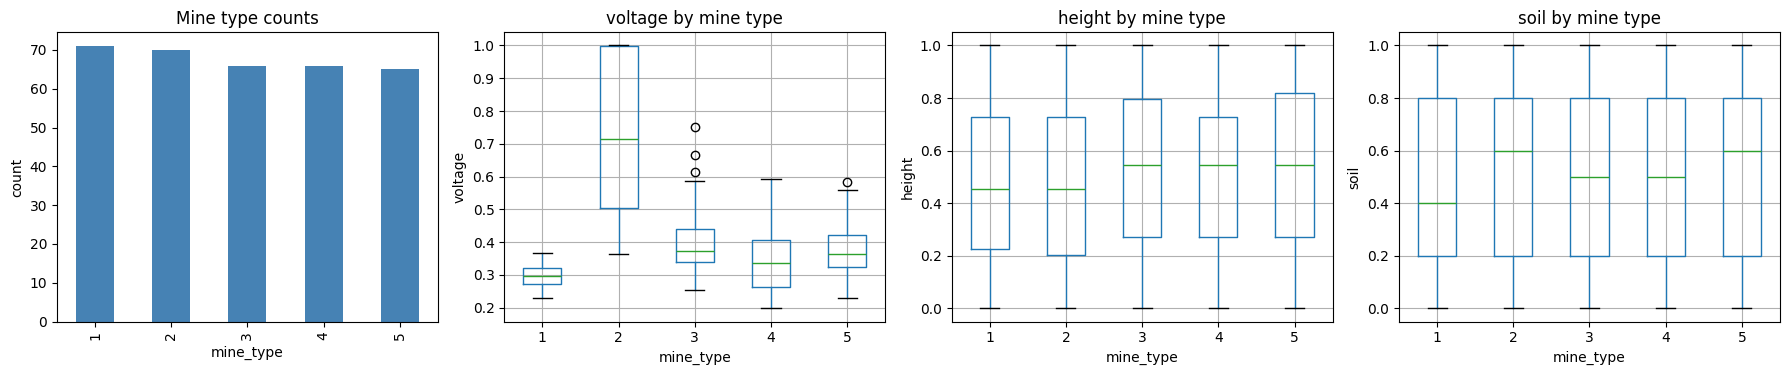

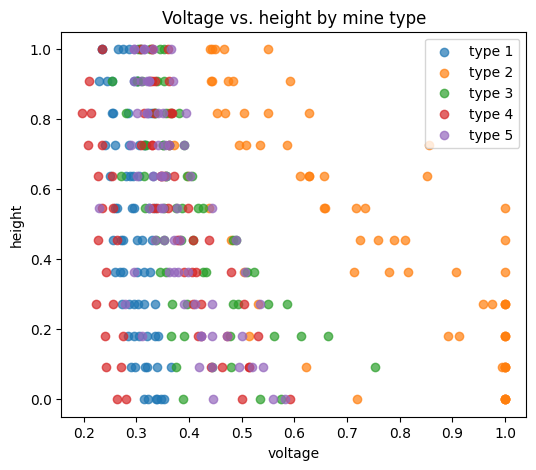

Best k: 2
training accuracy at k = 1: 1.0
training accuracy at best k: 0.7100591715976331
validation accuracy at best k: 0.46745562130177515


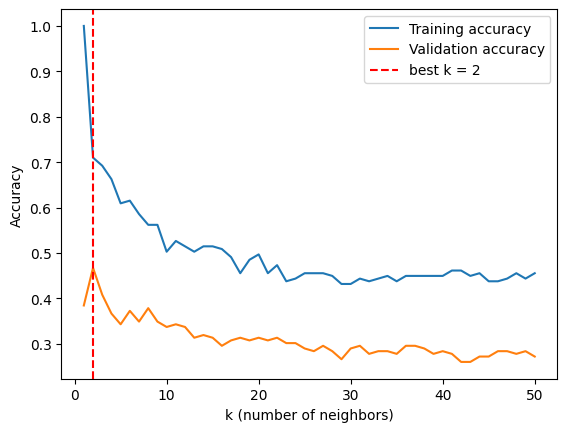

predicted   1   2   3   4  5
actual                      
1          27   0   5   2  2
2           0  31   2   1  1
3          10   2  10  10  1
4          15   6   3   9  0
5          15   0  10   5  2
accuracy: 0.46745562130177515 (chance is about 0.20)
        recall  precision  n actual  n predicted
actual                                          
1        0.750      0.403        36           67
2        0.886      0.795        35           39
3        0.303      0.333        33           30
4        0.273      0.333        33           27
5        0.062      0.333        32            6
type 3/4/5 mines labeled as type 1: 40 of 98
neighbors agree: n = 48 , accuracy = 0.625
neighbors disagree: n = 121 , accuracy = 0.4049586776859504
true type in neighbor shortlist: 0.6094674556213018
average shortlist size: 1.7159763313609468


In [2]:
#Question 2 -----

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

#loading data and EDA
lm = pd.read_csv("/content/land_mines.csv")
lm_features = ['voltage', 'height', 'soil']

print("shape:", lm.shape)
print('missing values per column:', lm.isna().sum()) #no missing values

#number of distinct values per feature (shows height and soil are discrete)
print('distinct values per feature:', lm[lm_features].nunique())

#summary stats for three features
print('feature summaries: ', lm[lm_features].describe())

#looking at amount of each mine type
print('mine type counts:', lm['mine_type'].value_counts().sort_index())

#printing mean and standard deviation of each feature by mine type
print('Mean:', lm.groupby('mine_type')[lm_features].mean())
print('Std dev:', lm.groupby('mine_type')[lm_features].std())

#correlations between features and label
print('Correlations:', lm[lm_features + ['mine_type']].corr())

#EDA plots: class counts and boxplot of each feature by mine type
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
lm['mine_type'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Mine type counts')
axes[0].set_xlabel('mine_type')
axes[0].set_ylabel('count')
for ax, f in zip(axes[1:], lm_features):
    lm.boxplot(column=f, by='mine_type', ax=ax)
    ax.set_title(f + ' by mine type')
    ax.set_xlabel('mine_type')
    ax.set_ylabel(f)
plt.suptitle('')
plt.tight_layout()
plt.show()

#EDA plot: voltage vs height colored by mine type
plt.figure(figsize=(6, 5))
for t in sorted(lm['mine_type'].unique()):
    sub = lm[lm['mine_type'] == t]
    plt.scatter(sub['voltage'], sub['height'], label=f'type {t}', alpha=0.7)
plt.xlabel('voltage')
plt.ylabel('height')
plt.title('Voltage vs. height by mine type')
plt.legend()
plt.show()


#spliting the sample into training and test/validation sets
lm_X_raw = lm[['voltage', 'height', 'soil']]
lm_y = lm['mine_type']
(
    lm_X_train_raw,
    lm_X_valid_raw,
    lm_y_train,
    lm_y_valid,
) = train_test_split(
    lm_X_raw, lm_y, test_size=0.50, stratify=lm_y, random_state=65
)

lm_scaler = MinMaxScaler()
lm_X_train_scaled = lm_scaler.fit_transform(lm_X_train_raw) #computing training data min and max and scaling the training features
lm_X_valid_scaled = lm_scaler.transform(lm_X_valid_raw) #using same values to scale the validation features

#building k-NN classifier and choosing k value
lm_ks = np.arange(1,51) #trying k values from 1-50
lm_valid_acc = [] #empty list to store each k's accucray on validation set
lm_train_acc = [] #empty list to store each k's accuracy on training set

for lm_k in lm_ks: #looping through for each k
  lm_candidate =KNeighborsClassifier(n_neighbors=int(lm_k)) #building k-NN model using k
  lm_candidate.fit(lm_X_train_scaled, lm_y_train) #learning from the training mines (k-NN storing them)
  lm_valid_hat = lm_candidate.predict(lm_X_valid_scaled) #guessing the mine type of every validation mine
  lm_train_hat = lm_candidate.predict(lm_X_train_scaled) #guess mine type for train set also
  lm_valid_acc.append(np.mean(lm_y_valid.to_numpy()== lm_valid_hat)) #saving correct validation guesses
  lm_train_acc.append(np.mean(lm_y_train.to_numpy()== lm_train_hat)) #saving correct training guesses

best_k = int(lm_ks[np.argmax(lm_valid_acc)]) #finding position of highest validation accuracy, finding that k value
print('Best k:', best_k)
print('training accuracy at k = 1:', lm_train_acc[0])
print('training accuracy at best k:', lm_train_acc[best_k - 1])
print('validation accuracy at best k:', lm_valid_acc[best_k - 1])

#creating plot of training v validation accuracy for each k, used to choose k
plt.plot(lm_ks, lm_train_acc, label='Training accuracy')
plt.plot(lm_ks, lm_valid_acc, label='Validation accuracy')
plt.axvline(best_k, color='red', linestyle='--', label=f'best k = {best_k}')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#print a confusion table
lm_final = KNeighborsClassifier(n_neighbors=best_k) #refitting model using the best k
lm_final.fit(lm_X_train_scaled, lm_y_train) #train on the training data
lm_pred = lm_final.predict(lm_X_valid_scaled) #predict the validation data

#creating confusion table, rows = actual and columns = predicted
lm_conf = pd.crosstab(lm_y_valid, lm_pred, rownames=['actual'], colnames=['predicted'])
print(lm_conf)

#printing overall accuracy
print('accuracy:', np.mean(lm_y_valid.to_numpy() == lm_pred), '(chance is about 0.20)')

#per-class recall (correct / actual) and precision (correct / predicted)
lm_cm = lm_conf.values
lm_report = pd.DataFrame({
    'recall': np.diag(lm_cm) / lm_cm.sum(axis=1),
    'precision': np.diag(lm_cm) / lm_cm.sum(axis=0),
    'n actual': lm_cm.sum(axis=1),
    'n predicted': lm_cm.sum(axis=0)}, index=lm_conf.index).round(3)
print(lm_report)
print('type 3/4/5 mines labeled as type 1:', lm_cm[2:, 0].sum(), 'of', lm_cm[2:].sum())

#using the neighbors as a confidence signal (used in the practical advice)
lm_dist, lm_idx = lm_final.kneighbors(lm_X_valid_scaled)
lm_nb = lm_y_train.to_numpy()[lm_idx] #labels of each validation mine's neighbors
lm_yv = lm_y_valid.to_numpy()
lm_agree = np.array([len(set(r)) == 1 for r in lm_nb]) #True if all neighbors have the same label
print('neighbors agree: n =', lm_agree.sum(), ', accuracy =', np.mean(lm_pred[lm_agree] == lm_yv[lm_agree]))
print('neighbors disagree: n =', (~lm_agree).sum(), ', accuracy =', np.mean(lm_pred[~lm_agree] == lm_yv[~lm_agree]))
lm_shortlist = [set(r) for r in lm_nb] #every mine type among the neighbors
print('true type in neighbor shortlist:', np.mean([lm_yv[i] in lm_shortlist[i] for i in range(len(lm_yv))]))
print('average shortlist size:', np.mean([len(s) for s in lm_shortlist]))




## Q1

**1. What is the difference between regression and classification?**

Regression predicts a numeric target (e.g., price), while classification predicts a categorical target (e.g., color or mine type). The label `mine_type` is stored as the integers 1-5, but these are unordered categories, so predicting it is classification. In k-NN, regression averages the neighbors' values, while classification takes a vote among the neighbors' labels. Regression error is measured with SSE or MSE, and classification error with accuracy and the confusion table.

**2. What is a confusion table? What does it help us understand about a model's performance?**

A confusion table counts predictions by actual class (rows) and predicted class (columns). The diagonal holds the correct predictions, and the off-diagonal cells show exactly which classes get mistaken for which. From it we can compute overall accuracy, per-class recall (correct / actual) and per-class precision (correct / predicted). It helps us see where a model is strong or weak and what kinds of mistakes it makes, which a single accuracy number hides.

**3. What does the SSE quantify about a particular model?**

The sum of squared errors (SSE) adds up (actual − predicted)² over all observations. It quantifies the total prediction error of a model for a numeric target: 0 is a perfect fit, and larger values mean worse predictions. Squaring means large misses are penalized much more than small ones. SSE grows with the number of observations, so models should be compared on the same data (or use MSE). A lower validation SSE means smaller errors on unseen data. SSE applies to numeric targets, so for class labels we use accuracy instead.

**4. What are overfitting and underfitting?**

Overfitting occurs when a model is too complex and learns noise or quirks of the training data instead of general patterns, so it performs very well on the training data but much worse on new data. In k-NN this happens when k is very small; at k = 1 each training point is its own nearest neighbor, so training accuracy is 100%. Underfitting occurs when a model is too simple or smooth to capture the important patterns, so it performs poorly on both the training data and new data. In k-NN this happens when k is very large, because predictions average over so many neighbors that real structure is washed out. We can spot both by comparing training performance with validation performance: a large gap suggests overfitting, and poor performance on both suggests underfitting.

**5. Why does splitting the data into training and testing sets, and choosing k by evaluating accuracy or SSE on the test set, improve model performance?**

A model's error on the data it was trained on is biased toward complex models. For example, k = 1 gets 100% training accuracy because every point is its own neighbor, so the training error cannot be used to choose k. If we instead fit each candidate model on a training set and evaluate it on separate held-out data, the held-out error mimics how the model would do on new, unseen data. Choosing the k with the best held-out performance therefore picks a model that balances overfitting and underfitting and generalizes better. Splitting does not change what any single model learns; it lets us select a better model. One caution is that if we choose k using the best score on the evaluation data and then report that same score, the reported score is optimistic, because the evaluation data helped select the model. For this reason, ideally we tune k on a validation set and keep a separate test set that is used only once for the final evaluation.

**6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.**

A class label gives one clear, simple prediction that is easy to interpret and act on. Its weaknesses are that it hides the model's confidence (a prediction made with 90% certainty looks the same as one made with 35% certainty), it forces a single fixed rule (pick the most likely class), and it cannot account for the different costs of different mistakes. A probability distribution shows how confident the model is in each class. It lets us set thresholds that reflect costs (for example, require high confidence before trusting a prediction, or send uncertain cases for review) and lets us rank cases by risk. Its weaknesses are that it is harder to interpret and communicate, the probabilities may be poorly calibrated (they may not match how often the model is actually right), and k-NN probabilities are coarse when k is small: with k = 2 the probability of a class can only be 0, 0.5, or 1. In the land mine data, a label alone cannot tell us that predictions where both neighbors agree were right more often (62.5%) than predictions where they disagreed (40.5%).

## Q2

**1-2. Data, EDA, and summary of labels and features.**

The data has 338 mines, 3 features, and no missing values. The label `mine_type` is roughly balanced across the five types (71, 70, 66, 66, and 65 mines), so no class dominates and chance accuracy is about 20%. All three features are already on a 0-1 scale. `voltage` is continuous (196 distinct values, range 0.198 to 1.0, mean 0.43, sd 0.20), while `height` (12 distinct values) and `soil` (6 distinct values) are discrete. `voltage` is the only feature that clearly differs by mine type: type 2 has a mean of 0.72 compared with 0.30 to 0.40 for the other types, and type 1 is tightly clustered (sd 0.03) while type 2 is widely spread (sd 0.22). The class means of `height` (0.49 to 0.53) and `soil` (0.49 to 0.52) are nearly identical across types, with similar spread, so on their own they carry little information. `voltage` and `height` are moderately negatively correlated (−0.38). From this I expect type 2 to be the easiest to predict and types 3, 4, and 5, which overlap in voltage, to be the hardest to tell apart.

**3. Split.**

I split the sample 50/50 into 169 training and 169 test/validation mines, stratified by `mine_type` so that every class appears in both halves (32 to 36 mines per class in each half). I fixed random_state = 65 so the results are reproducible.

**4. Building the k-NN classifier.**

k-NN classifies a mine by the labels of its closest training mines, and "closest" is measured by distance, so features on larger scales would dominate the distance. For this reason I rescaled the features with min-max scaling. I fit the scaler on the training data only and applied the same minimum and maximum to the validation data, so no information from the validation data leaks into training.

**5. Explain how you select k.**

I selected k by trying every value from 1 to 50, which covers flexible models (small k) and smooth models (large k). For each k, I fit a k-NN classifier on the training data and measured its accuracy on the validation half, which the model had not seen. I chose the k with the highest validation accuracy because it performed best on data it hadn't seen during training. This value was k = 2. The plot shows the tradeoff: training accuracy is 100% at k = 1 and 71% at k = 2, then keeps falling, while validation accuracy peaks at k = 2 (46.7%) and is only about 26% to 31% for k above 20. The gap between training accuracy (71%) and validation accuracy (46.7%) at k = 2 shows the model still overfits somewhat. One limitation is that I chose k using the same validation half whose accuracy I report, so 46.7% is an optimistic estimate of how the model would do on new mines. A separate final test set that is used only after k is chosen would give an unbiased estimate.

**6. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?**

(The table is printed in the code above.) The model is 46.7% accurate overall (79 of 169 mines), compared with about 20% from random guessing. Accuracy differs a lot by mine type, and it matters whether we look at recall (of the real mines of a type, how many did we find?) or precision (of the mines we labeled as a type, how many really were that type?):

- **Type 2** is the best on both: recall of 88.6% (31 of 35) and precision of 79.5% (31 of 39).
- **Type 1** shows how a type can have many correct predictions and still many mistakes. Its recall is 75% (27 of 36), but the model labeled 67 mines as type 1 when only 36 are type 1, so its precision is only 40.3% (27 of 67) and about 60% of "type 1" predictions are wrong. In particular, 40 of the 98 mines of types 3, 4, and 5 were labeled as type 1.
- **Types 3 and 4** are weak: recall is 30.3% (10 of 33) for type 3 and 27.3% (9 of 33) for type 4, and precision is 33.3% for each, only modestly better than chance.
- **Type 5** is the worst: recall is only 6.3% (2 of 32). The model labeled only 6 mines as type 5, so most real type 5 mines get labeled as another type. Its 33.3% precision rests on only 6 predictions.

This matches the EDA: type 2 is separated by its distinctive voltage, while types 3, 4, and 5 overlap heavily in voltage and are not separated by `height` or `soil`.

**7. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.**

First, I would advise against treating the predicted label as a final answer; it should be used to screen or narrow the possibilities. A "type 2" prediction is fairly reliable (79.5% precision, 88.6% recall). A "type 1" prediction is not: about 60% of them are wrong, and many are really type 3, 4, or 5 mines. Predictions of types 3, 4, and 5 are right only about a third of the time, and a real type 5 mine is almost always labeled as something else (30 of 32).

Second, I would use the neighbors as a confidence signal. When both neighbors agree (48 validation mines), the prediction was correct 62.5% of the time, compared with 40.5% when they disagreed (121 mines). A better way to report results is a shortlist of the mine types among the neighbors: it contained the true type 61% of the time, with an average of 1.7 candidate types. This is more honest than a single label. These estimates are rough, because they rest on small groups of mines, and with k = 2 the probabilities can only be 0, 0.5, or 1; a larger k would give finer probabilities.

Third, because mistakes can be costly, I would confirm the prediction with other information before removing a mine, such as another sensor reading, visual inspection, and expert judgment. Any mine that is not confidently identified should be handled with the most cautious procedure. This is especially important for types 1, 3, 4, and 5, where the model makes the most mistakes.

Fourth, I would improve the model by collecting more training data, especially for types 3, 4, and 5, and by collecting more informative measurements. `height` and `soil` have nearly identical class means, so they appear to add little, and `voltage` is doing most of the work. I would also judge future versions by per-type precision and recall, not only overall accuracy.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The AI suggestions mainly helped me improve the depth of my answers to the qualitative questions. AI helped me write more thorough explanations to each part of question one and two to add more clarity. It suggested adding EDA plots and a written summary, which explained why I scaled the features and fit the model on training data only to strengthen my question 1 responses. The AI suggested changing how I chose k, saying k = 2 was fragile and that odd k would avoid ties. When it tested this, odd k still produced ties (34% of mines at k = 3) because there are five classes, and accuracy dropped to 40.8%. I rejected those changes because my original code already followed the assignment's method of choosing k on the validation set. The AI also drafted numbers that I had to check rather than trust. The AI also caught some typos in my work which were corrected. To verify that these changes were correctly implemented, I reran my code and confirmed that my k value produced the same accuracy score as before. I don't have any remaining concerns about the things AI changed after rejecting the suggestion to change the k value. Overall, the AI did a pretty good job but of course always needs to be verified and double checked.